In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("20_Mobile_Price_Classification.csv")
df.head()

print("Shape:", df.shape)
print("Missing values:")
print(df.isnull().sum())
print("\nClass distribution:")
print(df["price_range"].value_counts().sort_index())

Shape: (2000, 21)
Missing values:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Class distribution:
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


In [96]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", y.nunique())

Number of samples: 2000
Number of features: 20
Number of classes: 4


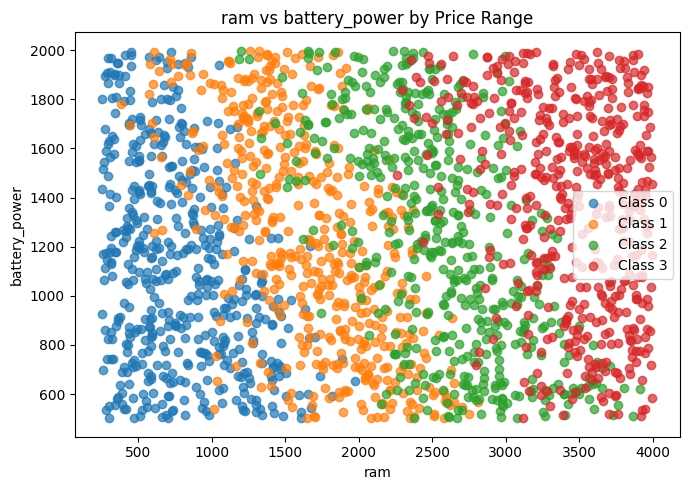

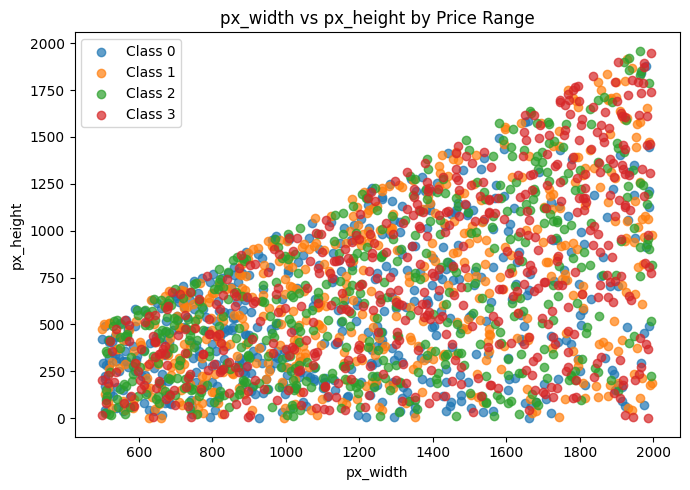

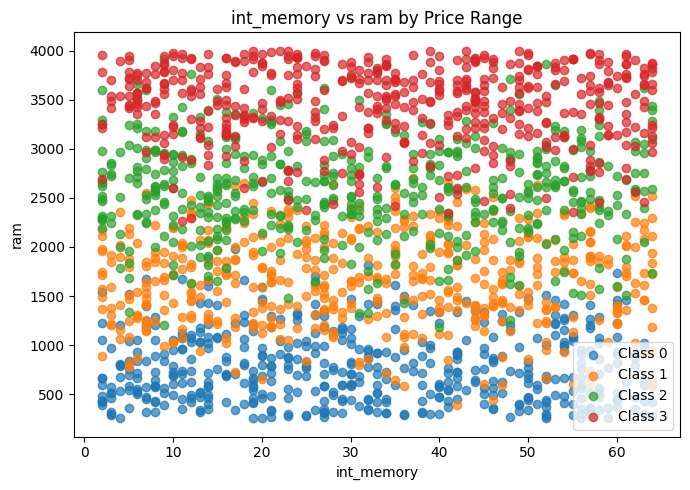

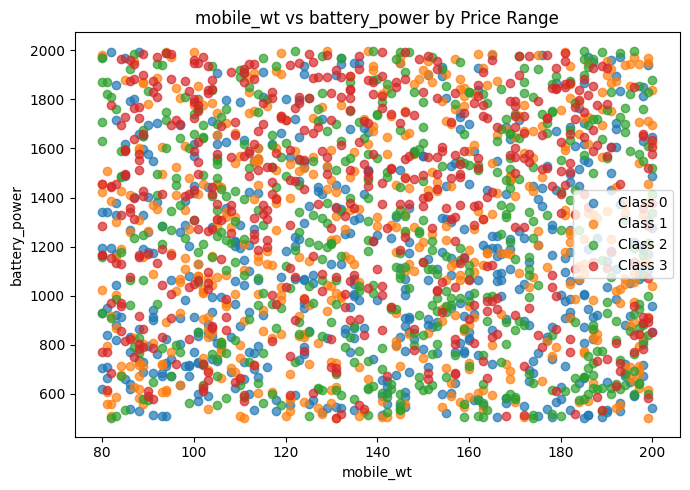

In [97]:
plot_pairs = [("ram", "battery_power"), ("px_width", "px_height"), ("int_memory", "ram"), ("mobile_wt", "battery_power")]

for x_col, y_col in plot_pairs:
    plt.figure(figsize=(7,5))
    for cls in sorted(df["price_range"].unique()):
        subset = df[df["price_range"] == cls]
        plt.scatter(subset[x_col], subset[y_col], label=f"Class {cls}", alpha=0.7)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col} by Price Range")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [98]:
def specificity_macro(y_true, y_pred) :
  cm = confusion_matrix(y_true, y_pred)
  specificities = []

  for i in range(cm.shape[0]) :
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum()- tp
    tn = cm.sum() - (tp + fn + fp)

    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    specificities.append(specificity)

  return np.mean(specificities)

def get_metrics(y_true, y_pred) :
  return {
      "Accuracy": accuracy_score(y_true, y_pred),
      "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
      "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
      "Sensitivity": recall_score(y_true, y_pred, average="macro", zero_division=0),
      "Specificity": specificity_macro(y_true, y_pred),
      "F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0)
  }

In [99]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y, cv) :
  results = []

  for fold, (train_index, test_index) in enumerate(cv.split(X, y), start= 1) :
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = get_metrics(y_test, y_pred)
    metrics["Fold"] = fold
    results.append(metrics)

  return pd.DataFrame(results)

In [100]:
k_values = [3, 5, 7, 9, 11, 13]
knn_results = []

for k in k_values :
  knn_model = Pipeline([
      ("scaler", StandardScaler()),
      ("classifier", KNeighborsClassifier(n_neighbors=k))
  ])

  fold_results = evaluate_model(knn_model, X, y, cv)
  avg_results = fold_results.drop("Fold", axis=1).mean()
  avg_results["K"] = k
  knn_results.append(avg_results)

knn_summary = pd.DataFrame(knn_results)
knn_summary = knn_summary[["K", "Accuracy", "Precision", "Recall", "Sensitivity", "Specificity", "F1-score"]]

knn_summary

,K,Accuracy,Precision,Recall,Sensitivity,Specificity,F1-score
0,3.0,0.4775,0.495581,0.4775,0.4775,0.825833,0.476001
1,5.0,0.5120,0.536020,0.5120,0.5120,0.837333,0.515431
2,7.0,0.5335,0.545269,0.5335,0.5335,0.844500,0.535575
3,9.0,0.5520,0.562901,0.5520,0.5520,0.850667,0.553246
4,11.0,0.5645,0.575016,0.5645,0.5645,0.854833,0.566276
5,13.0,0.5775,0.587435,0.5775,0.5775,0.859167,0.579766


In [101]:
best_k = int(knn_summary.sort_values("Accuracy", ascending=False).iloc[0]["K"])
print("Best K:", best_k)

best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=best_k))
])

knn_folds = evaluate_model(best_knn, X, y, cv)
knn_folds

Best K: 13


,Accuracy,Precision,Recall,Sensitivity,Specificity,F1-score,Fold
0,0.5775,0.584955,0.5775,0.5775,0.859167,0.578815,1
1,0.6025,0.606807,0.6025,0.6025,0.867500,0.603355,2
2,0.5650,0.587779,0.5650,0.5650,0.855000,0.569961,3
3,0.5700,0.573095,0.5700,0.5700,0.856667,0.570911,4
4,0.5725,0.584539,0.5725,0.5725,0.857500,0.575790,5


In [102]:
knn_mean = knn_folds.drop("Fold", axis=1).mean()
knn_std = knn_folds.drop("Fold", axis=1).std()

print("KNN Mean:")
print(knn_mean)

print("\nKNN Standard Deviation:")
print(knn_std)

KNN Mean:
Accuracy       0.577500
Precision      0.587435
Recall         0.577500
Sensitivity    0.577500
Specificity    0.859167
F1-score       0.579766
dtype: float64

KNN Standard Deviation:
Accuracy       0.014684
Precision      0.012202
Recall         0.014684
Sensitivity    0.014684
Specificity    0.004895
F1-score       0.013672
dtype: float64


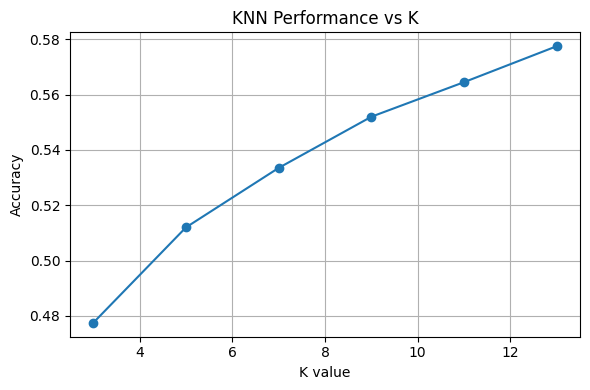

In [103]:
plt.figure(figsize=(6,4))
plt.plot(knn_summary["K"], knn_summary["Accuracy"], marker="o")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN Performance vs K")
plt.grid()
plt.tight_layout()
plt.show()

In [104]:
svm_configs = [
    ("linear", 1, "scale"),
    ("rbf", 1, "scale"),
    ("rbf", 10, "scale"),
    ("poly", 1, "scale")
]

svm_results = []

for kernel, C, gamma in svm_configs:
    svm_model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel=kernel, C=C, gamma=gamma))
    ])

    fold_results = evaluate_model(svm_model, X, y, cv)
    avg_results = fold_results.drop("Fold", axis=1).mean()
    avg_results["Kernel"] = kernel
    avg_results["C"] = C
    svm_results.append(avg_results)

svm_summary = pd.DataFrame(svm_results)
svm_summary = svm_summary[["Kernel", "C", "Accuracy", "Precision", "Recall", "Sensitivity", "Specificity", "F1-score"]]

svm_summary

,Kernel,C,Accuracy,Precision,Recall,Sensitivity,Specificity,F1-score
0,linear,1,0.9615,0.962289,0.9615,0.9615,0.987167,0.961413
1,rbf,1,0.8770,0.879835,0.8770,0.8770,0.959000,0.877667
2,rbf,10,0.8855,0.886921,0.8855,0.8855,0.961833,0.885452
3,poly,1,0.7775,0.789301,0.7775,0.7775,0.925833,0.780988


In [105]:
best_svm_row = svm_summary.sort_values("Accuracy", ascending=False).iloc[0]
best_kernel = best_svm_row["Kernel"]
best_C = best_svm_row["C"]

print("Best SVM Kernel:", best_kernel)
print("Best C:", best_C)

best_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel=best_kernel, C=best_C, gamma="scale"))
])

svm_folds = evaluate_model(best_svm, X, y, cv)
svm_folds

Best SVM Kernel: linear
Best C: 1


,Accuracy,Precision,Recall,Sensitivity,Specificity,F1-score,Fold
0,0.9600,0.960496,0.9600,0.9600,0.986667,0.959818,1
1,0.9750,0.975261,0.9750,0.9750,0.991667,0.974918,2
2,0.9550,0.955403,0.9550,0.9550,0.985000,0.954936,3
3,0.9575,0.958613,0.9575,0.9575,0.985833,0.957837,4
4,0.9600,0.961669,0.9600,0.9600,0.986667,0.959556,5


In [106]:
svm_mean = svm_folds.drop("Fold", axis=1).mean()
svm_std = svm_folds.drop("Fold", axis=1).std()

print("SVM Mean:")
print(svm_mean)

print("\nSVM Standard Deviation:")
print(svm_std)

SVM Mean:
Accuracy       0.961500
Precision      0.962289
Recall         0.961500
Sensitivity    0.961500
Specificity    0.987167
F1-score       0.961413
dtype: float64

SVM Standard Deviation:
Accuracy       0.007826
Precision      0.007629
Recall         0.007826
Sensitivity    0.007826
Specificity    0.002609
F1-score       0.007796
dtype: float64


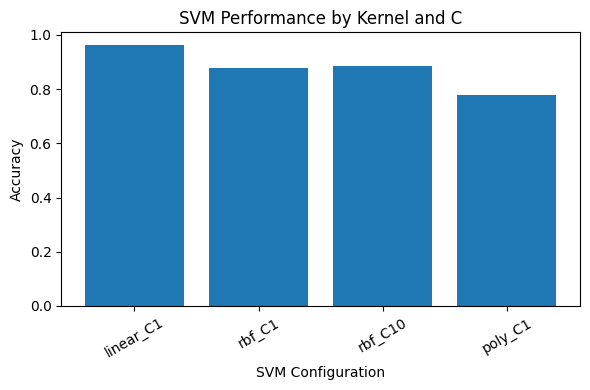

In [107]:
plt.figure(figsize=(6,4))
plt.bar(svm_summary["Kernel"] + "_C" + svm_summary["C"].astype(str), svm_summary["Accuracy"])
plt.xlabel("SVM Configuration")
plt.ylabel("Accuracy")
plt.title("SVM Performance by Kernel and C")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [108]:
mlp_configs = [
    (100,),
    (64,),
    (100, 50),
    (64, 32)
]

mlp_results = []

for hidden_layers in mlp_configs:
    mlp_model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation="relu",
            solver="adam",
            max_iter=500,
            random_state=42
        ))
    ])

    fold_results = evaluate_model(mlp_model, X, y, cv)
    avg_results = fold_results.drop("Fold", axis=1).mean()
    avg_results["Architecture"] = str(hidden_layers)
    mlp_results.append(avg_results)

mlp_summary = pd.DataFrame(mlp_results)
mlp_summary = mlp_summary[["Architecture", "Accuracy", "Precision", "Recall", "Sensitivity", "Specificity", "F1-score"]]

mlp_summary



,Architecture,Accuracy,Precision,Recall,Sensitivity,Specificity,F1-score
0,"(100,)",0.9195,0.920414,0.9195,0.9195,0.973167,0.919542
1,"(64,)",0.9225,0.923663,0.9225,0.9225,0.974167,0.922491
2,"(100, 50)",0.9070,0.908417,0.9070,0.9070,0.969000,0.906908
3,"(64, 32)",0.9230,0.924483,0.9230,0.9230,0.974333,0.923115


In [109]:
best_mlp_arch = mlp_summary.sort_values("Accuracy", ascending=False).iloc[0]["Architecture"]

if best_mlp_arch == "(100,)":
    hidden_layers = (100,)
elif best_mlp_arch == "(64,)":
    hidden_layers = (64,)
elif best_mlp_arch == "(100, 50)":
    hidden_layers = (100, 50)
else:
    hidden_layers = (64, 32)

print("Best MLP architecture:", hidden_layers)

best_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

mlp_folds = evaluate_model(best_mlp, X, y, cv)
mlp_folds

Best MLP architecture: (64, 32)


,Accuracy,Precision,Recall,Sensitivity,Specificity,F1-score,Fold
0,0.920,0.920657,0.920,0.920,0.973333,0.919658,1
1,0.935,0.935649,0.935,0.935,0.978333,0.935137,2
2,0.915,0.916815,0.915,0.915,0.971667,0.915236,3
3,0.910,0.912110,0.910,0.910,0.970000,0.910536,4
4,0.935,0.937185,0.935,0.935,0.978333,0.935010,5


In [110]:
mlp_mean = mlp_folds.drop("Fold", axis=1).mean()
mlp_std = mlp_folds.drop("Fold", axis=1).std()

print("MLP Mean:")
print(mlp_mean)

print("\nMLP Standard Deviation:")
print(mlp_std)

MLP Mean:
Accuracy       0.923000
Precision      0.924483
Recall         0.923000
Sensitivity    0.923000
Specificity    0.974333
F1-score       0.923115
dtype: float64

MLP Standard Deviation:
Accuracy       0.011511
Precision      0.011319
Recall         0.011511
Sensitivity    0.011511
Specificity    0.003837
F1-score       0.011383
dtype: float64


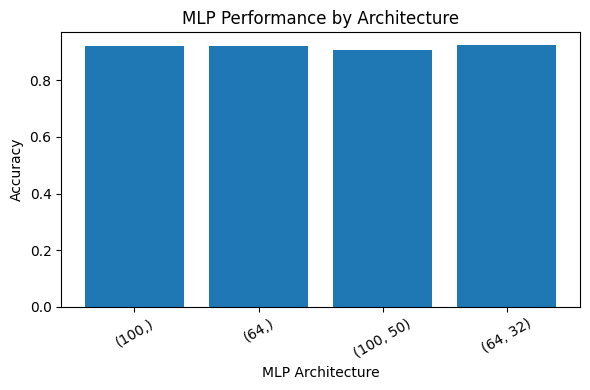

In [111]:
plt.figure(figsize=(6,4))
plt.bar(mlp_summary["Architecture"], mlp_summary["Accuracy"])
plt.xlabel("MLP Architecture")
plt.ylabel("Accuracy")
plt.title("MLP Performance by Architecture")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [112]:
final_comparison = pd.DataFrame({
    "KNN": knn_folds.drop("Fold", axis=1).mean(),
    "SVM": svm_folds.drop("Fold", axis=1).mean(),
    "MLP": mlp_folds.drop("Fold", axis=1).mean()
}).T

final_comparison

,Accuracy,Precision,Recall,Sensitivity,Specificity,F1-score
KNN,0.5775,0.587435,0.5775,0.5775,0.859167,0.579766
SVM,0.9615,0.962289,0.9615,0.9615,0.987167,0.961413
MLP,0.9230,0.924483,0.9230,0.9230,0.974333,0.923115


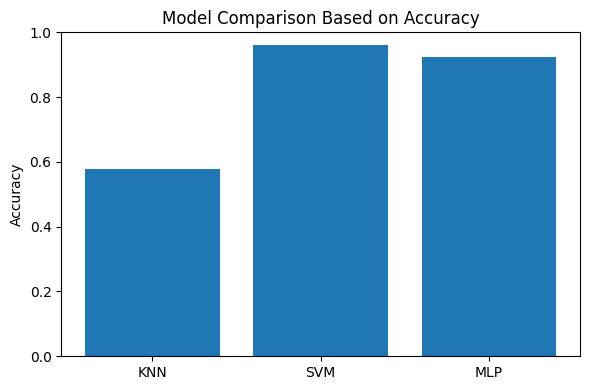

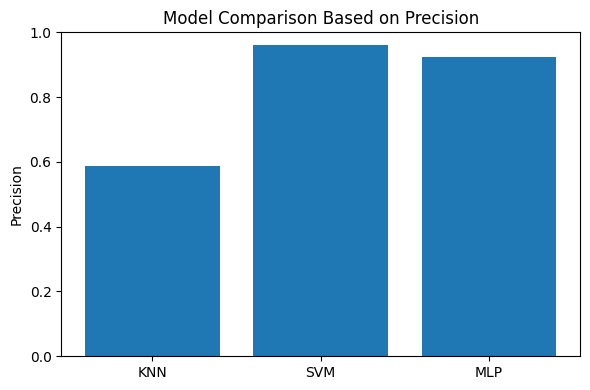

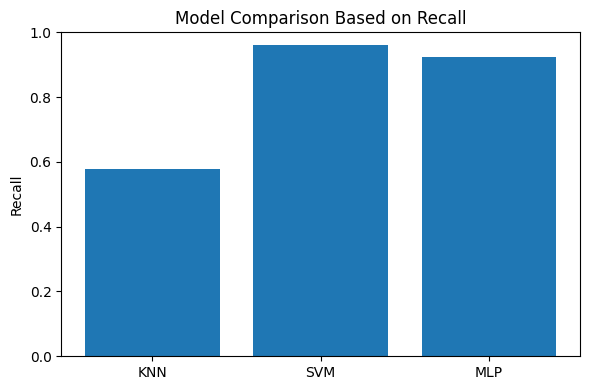

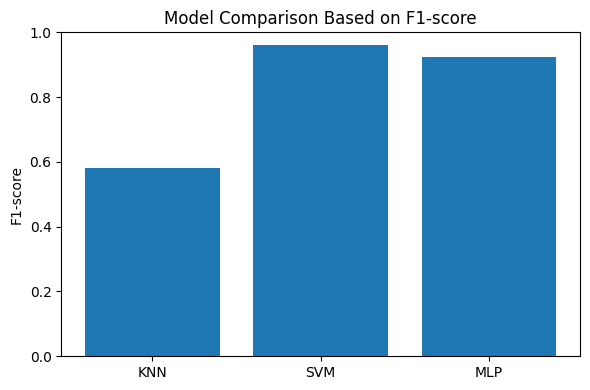

In [113]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6,4))
    plt.bar(final_comparison.index, final_comparison[metric])
    plt.ylim(0, 1)
    plt.ylabel(metric)
    plt.title(f"Model Comparison Based on {metric}")
    plt.tight_layout()
    plt.show()


KNN Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70       500
           1       0.43      0.46      0.44       500
           2       0.48      0.48      0.48       500
           3       0.77      0.63      0.69       500

    accuracy                           0.58      2000
   macro avg       0.59      0.58      0.58      2000
weighted avg       0.59      0.58      0.58      2000



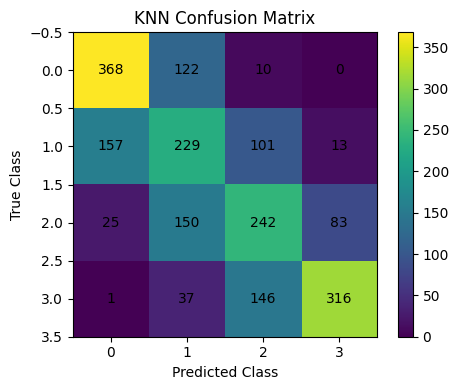


SVM Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       500
           1       0.95      0.94      0.95       500
           2       0.96      0.94      0.95       500
           3       0.96      0.99      0.98       500

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



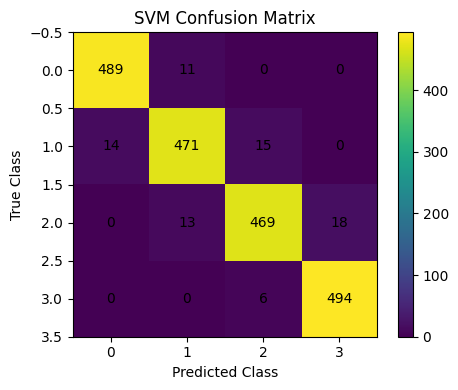


MLP Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       500
           1       0.90      0.91      0.90       500
           2       0.91      0.90      0.90       500
           3       0.95      0.94      0.94       500

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



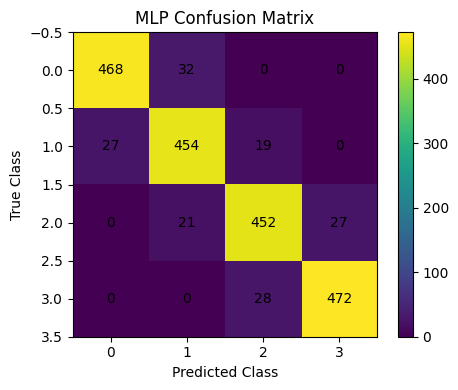

In [114]:
models = {
    "KNN": best_knn,
    "SVM": best_svm,
    "MLP": best_mlp
}

for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=cv)
    cm = confusion_matrix(y, y_pred)

    print(f"\n{name} Classification Report:")
    print(classification_report(y, y_pred))

    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()